In [2]:
import tensorflow as tf
print(tf)

<module 'tensorflow' from '/usr/local/lib/python3.11/dist-packages/tensorflow/__init__.py'>


In [11]:
from tensorflow.keras import layers, models, Model
from tensorflow.keras.layers import Conv2D, BatchNormalization, Input
# Alternative: Simpler CNN with Pixel Shuffle approach
def build_model(sinogram_shape, image_shape, num_filters=64):
    """
    Build a simpler CNN model with pixel shuffle for sinogram reconstruction
    Based on research showing good results with dense 2D convolutions
    """

    inputs = Input(shape=(*sinogram_shape,1))

    # Feature extraction layers
    x = Conv2D(num_filters, 3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = Conv2D(num_filters, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = Conv2D(num_filters*2, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = Conv2D(num_filters*2, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = Conv2D(num_filters*4, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    # Reconstruction layers
    x = Conv2D(num_filters*2, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = Conv2D(num_filters, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    # Resize to target image dimensions
    if sinogram_shape[:2] != image_shape[:2]:
        x = layers.Resizing(image_shape[0], image_shape[1])(x)


    # Output layer
    outputs = Conv2D(image.shape[1], 3, padding='same', activation='linear')(x)

    model = Model(inputs=inputs, outputs=outputs, name='simpleCNN')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='mse',
        metrics=['mae', 'mse']
    )

    return model

In [4]:
from skimage import io
from skimage.transform import resize
image = io.imread('/content/demo.jpg', as_gray = True)
image = resize(image, (256,256))

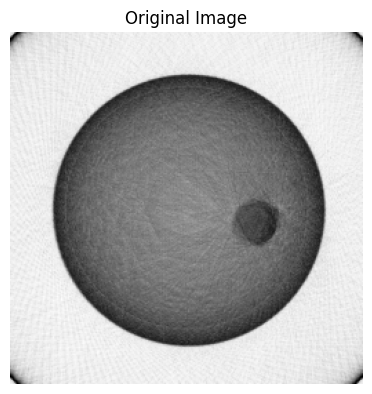

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
# Display the original image
plt.subplot(1, 2, 1)
plt.imshow(image, cmap=plt.cm.Greys_r)
plt.title('Original Image')
plt.axis('off')
plt.show()

In [6]:
image.shape

(256, 256)

In [7]:
from skimage.transform import radon
from skimage.color import rgb2gray
import numpy as np

# Apply the radon transform to the grayscale image
sinogram = radon(image, theta=np.linspace(0., 180., max(image.shape), endpoint=False), circle = False)

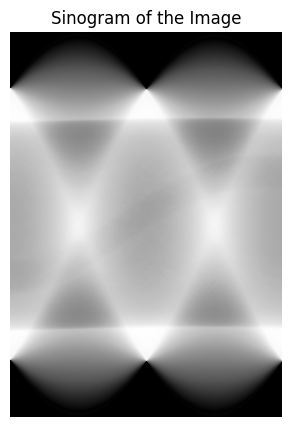

In [8]:
plt.figure(figsize=(10, 5))
# Display the original image
plt.subplot(1, 2, 1)
plt.imshow(sinogram, cmap = plt.cm.Greys_r)
plt.title('Sinogram of the Image')
plt.axis('off')
plt.show()

In [9]:
sinogram.shape

(363, 256)

In [12]:
# Build the model with the shape of the sinogram including the channel dimension
model = build_model(sinogram.shape, image.shape)

In [13]:
model.summary()

Model: "SinogramToImage_SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 363, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 363, 256, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 363, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 363, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 363, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 363, 256, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 363, 256, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 363, 256, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 363, 256, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 363, 256, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 363, 256, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 363, 256, 128)  │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 363, 256, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 363, 256, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 363, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 256, 256, 256)  │       147,712 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,074,048 (4.10 MB)

 Trainable params: 1,072,384 (4.09 MB)

 Non-trainable params: 1,664 (6.50 KB)

### Displaying Prediction on sample input

In [15]:
sinogram.shape

(363, 256)

In [17]:

# Make a prediction using the model
prediction_sinogram = model.predict(sinogram)

ValueError: Input 0 of layer "SinogramToImage_SimpleCNN" is incompatible with the layer: expected shape=(None, 363, 256, 1), found shape=(32, 256)

In [ ]:
# Remove the batch dimension and single channel dimension from the prediction
# np.squeeze removes dimensions of size 1
prediction_to_plot = np.squeeze(prediction_sinogram)

plt.figure(figsize=(10, 5))
# Display the prediction
plt.subplot(1, 1, 1) # Use 1,1,1 for a single plot
plt.imshow(prediction_to_plot, cmap = plt.cm.Greys_r)
plt.title('Prediction')
plt.axis('off')
plt.show()

### Preparing training and testing datasets

In [ ]:
import os
base_dir = '.'
dataset = 'brain_CT'
output_folder = os.path.join(base_dir, dataset)
input_folder = os.path.join(base_dir, f"{dataset}_sinograms")

In [ ]:
X = np.ndarray((0, 256, 256, 1), dtype=np.float32)
Y = np.ndarray((0, 256, 256, 3), dtype=np.float32)

In [ ]:
import skimage.io as io
import numpy as np
import os

X_list = []
Y_list = []

expected_x_shape = X.shape[1:]
expected_y_shape = Y.shape[1:]

for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        # Read images
        try:
            input_image = io.imread(input_path, as_gray=False)
            output_image = io.imread(output_path)
        except Exception as e:
            print(f"Error reading image files {filename}: {e}")
            continue # Skip to the next file if there's an error reading

        # Add channel dimension if needed (for grayscale images)
        if input_image.ndim == 2:
            input_image = np.expand_dims(input_image, axis=-1)
        if output_image.ndim == 2:
            output_image = np.expand_dims(output_image, axis=-1)

        # for batch
        input_image_with_batch = np.expand_dims(input_image, axis = 0)

        # Check if the image shapes match the expected shapes before appending
        if input_image.shape == expected_x_shape:
            X_list.append(input_image_with_batch)
        else:
            print(f"Skipping input image {filename} due to unexpected shape: {input_image.shape}. Expected: {expected_x_shape}")

        if output_image.shape == expected_y_shape:
            Y_list.append(output_image)
        else:
             print(f"Skipping output image {filename} due to unexpected shape: {output_image.shape}. Expected: {expected_y_shape}")


# Convert lists to numpy arrays
# Only attempt conversion if lists are not empty
if X_list and Y_list:
    X = np.array(X_list, dtype=np.float32)
    Y = np.array(Y_list, dtype=np.float32)

    print(f"Loaded {len(X_list)} images into X and {len(Y_list)} images into Y")
    print(f"Shape of X: {X.shape}")
    print(f"Shape of Y: {Y.shape}")
else:
    print("No images with the expected shapes were found.")

In [ ]:
X_train = X[:100]
Y_train = Y[:100]
X_test = X[101:]
Y_test = Y[101:]

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error is a common loss for regression tasks like image reconstruction
    metrics=['mae'] # Mean Absolute Error is a useful metric to see the average pixel difference
)

In [ ]:
history = model.fit(X_train, Y_train, epochs=10, batch_size=32)